In [169]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.figsize'] = [7, 5]

# HEALTH CHECK

In [170]:
#clients_amount * client_fractions * noisy * bias * algorithms + baselines
#3 * 2 * 2 * 2 * 2 + 2 = 50

In [171]:
from collections import Counter

def health_check(data):
    assert Counter(data['parameters/clients_amount'])[1] == 2, f'Expected 2 baselines, got {Counter(data["parameters/clients_amount"])[1]}'
    assert Counter(data['parameters/experiment'].str.contains('noisy').astype(str))['True'] == 24, f'Expected 24 noisy experiments, got {Counter(data["parameters/experiment"].str.contains("noisy").astype(str))}'
    assert Counter(data['parameters/client_fraction'])[0.5] == 24, f'Expected 24 0.5 experiments, got {Counter(data["parameters/client_fraction"])}'
    assert Counter(data['parameters/iid_dataset'])['biased'] == 24, f'Expected 24 biased experiments, got {Counter(data["parameters/iid_dataset"])}'
    assert len(data) == 50, f'Expected 50 rows, got {len(data)}'

In [172]:
exp_type = '_cv_auc'
datasets = [f'breast_cancer{exp_type}', f'pen_global{exp_type}', f'letter{exp_type}', f'satellite{exp_type}']
path = '/Users/maxfrax/Desktop/Thesis/Results/Paper Analysis'

# La mia tecnica è efficace per anomaly detection?

In [185]:
table = []
exp_table = []

for dataset in datasets:
    data = pd.read_csv(f'/Users/maxfrax/Downloads/{dataset}.csv')

    data['results/pretty_auc'] = data[['results/avg_auc', 'results/std_auc']].apply(lambda x: f'{x[0]:.2f} ± {x[1]:1.0E}', axis=1)

    try:
        health_check(data)
    except:
        print(f'Failed for {dataset}')
        raise

    data['exp'] = data['parameters/clients_amount'].astype(str) + ',' + data['parameters/client_fraction'].astype(str) +','+data['parameters/iid_dataset'] + ',' + data['parameters/experiment']

    table.append({
        'dataset': dataset.replace(exp_type, '').replace('_', ' ').title()[0],
        'oc-SVM': data[data['parameters/experiment'] == 'baseline_sklearn'].iloc[0]['results/pretty_auc'],
        'SVDD': data[data['parameters/experiment'] == 'baseline_svdd'].iloc[0]['results/pretty_auc'],
        'Best  SVE': data.iloc[data[data['parameters/experiment'] == 'dp_flbsv_noisy']['results/avg_auc'].idxmax()]['results/pretty_auc'],
        'Best  ESVDD': data.iloc[data[data['parameters/experiment'] == 'ensemble_flbsv_noisy']['results/avg_auc'].idxmax()]['results/pretty_auc'],
        'Worst  SVE': data.iloc[data[data['parameters/experiment'] == 'dp_flbsv_noisy']['results/avg_auc'].idxmin()]['results/pretty_auc'],
        'Worst ESVDD': data.iloc[data[data['parameters/experiment'] == 'ensemble_flbsv_noisy']['results/avg_auc'].idxmin()]['results/pretty_auc'],
    })

    exp_table.append({
        'dataset': dataset.replace(exp_type, '').replace('_', ' ').title(),
        'oc-SVM': data[data['parameters/experiment'] == 'baseline_sklearn'].iloc[0]['exp'],
        'SVDD': data[data['parameters/experiment'] == 'baseline_svdd'].iloc[0]['exp'],
        'Best  SVE': data.iloc[data[data['parameters/experiment'] == 'dp_flbsv_noisy']['results/avg_auc'].idxmax()]['exp'],
        'Best  ESVDD': data.iloc[data[data['parameters/experiment'] == 'ensemble_flbsv_noisy']['results/avg_auc'].idxmax()]['exp'],
        'Worst  SVE': data.iloc[data[data['parameters/experiment'] == 'dp_flbsv_noisy']['results/avg_auc'].idxmin()]['exp'],
        'Worst ESVDD': data.iloc[data[data['parameters/experiment'] == 'ensemble_flbsv_noisy']['results/avg_auc'].idxmin()]['exp'],
    })

,Id,parameters/clients_amount,parameters/iid_dataset,parameters/client_fraction,parameters/experiment,results/avg_auc,results/std_auc,results/std_acc,results/avg_acc,results/pretty_auc,results/pretty_acc
2,FLOD-1228,10,iid,1.0,ensemble_flbsv_noisy,0.981326,0.008659,0.026770,0.852459,0.9813 ± 0.0087,0.8525 ± 0.0268
22,FLOD-1208,2,iid,0.5,ensemble_flbsv_noisy,0.979458,0.003494,0.021514,0.866120,0.9795 ± 0.0035,0.8661 ± 0.0215
4,FLOD-1226,10,biased,0.5,ensemble_flbsv_noisy,0.977591,0.012102,0.027048,0.587432,0.9776 ± 0.0121,0.5874 ± 0.0270
6,FLOD-1224,10,iid,0.5,ensemble_flbsv_noisy,0.971989,0.016493,0.010223,0.800546,0.9720 ± 0.0165,0.8005 ± 0.0102
12,FLOD-1218,5,biased,0.5,ensemble_flbsv_noisy,0.969188,0.006051,0.043027,0.357923,0.9692 ± 0.0061,0.3579 ± 0.0430
14,FLOD-1216,5,iid,0.5,ensemble_flbsv_noisy,0.968254,0.019452,0.020446,0.816940,0.9683 ± 0.0195,0.8169 ± 0.0204
18,FLOD-1212,2,iid,1.0,ensemble_flbsv_noisy,0.962652,0.016859,0.021514,0.887978,0.9627 ± 0.0169,0.8880 ± 0.0215
10,FLOD-1220,5,iid,1.0,ensemble_flbsv_noisy,0.957983,0.023212,0.021514,0.879781,0.9580 ± 0.0232,0.8798 ± 0.0215
16,FLOD-1214,2,biased,1.0,ensemble_flbsv_noisy,0.955182,0.029200,0.025338,0.898907,0.9552 ± 0.0292,0.8989 ± 0.0253
0,FLOD-1230,10,biased,1.0,ensemble_flbsv_noisy,0.949580,0.045913,0.026770,0.762295,0.9496 ± 0.0459,0.7623 ± 0.0268


In [174]:
# Best average AUC result with noise
res = pd.DataFrame(table)

res.to_latex(f'{path}/results{exp_type}.tex', index=False)

res

,dataset,oc-SVM,SVDD,Best SVE,Best ESVDD,Worst SVE,Worst ESVDD
0,B,0.98 ± 7E-03,0.96 ± 3E-02,0.99 ± 5E-03,0.98 ± 9E-03,0.71 ± 2E-01,0.86 ± 1E-01
1,P,0.96 ± 1E-02,0.79 ± 6E-02,0.84 ± 8E-03,0.88 ± 1E-02,0.55 ± 2E-01,0.50 ± 3E-02
2,L,0.59 ± 4E-02,0.57 ± 3E-02,0.59 ± 2E-02,0.78 ± 2E-02,0.51 ± 5E-02,0.54 ± 2E-02
3,S,0.92 ± 8E-03,0.78 ± 8E-02,0.82 ± 4E-02,0.89 ± 3E-02,0.56 ± 2E-01,0.68 ± 2E-01


In [175]:
experiments = pd.DataFrame(exp_table)

experiments.to_latex(f'{path}/experiments{exp_type}.tex', index=False)

experiments

,dataset,oc-SVM,SVDD,Best SVE,Best ESVDD,Worst SVE,Worst ESVDD
0,Breast Cancer,"1,1.0,iid,baseline_sklearn","1,1.0,iid,baseline_svdd","2,0.5,biased,dp_flbsv_noisy","10,1.0,iid,ensemble_flbsv_noisy","5,0.5,biased,dp_flbsv_noisy","2,0.5,biased,ensemble_flbsv_noisy"
1,Pen Global,"1,1.0,iid,baseline_sklearn","1,1.0,iid,baseline_svdd","5,0.5,iid,dp_flbsv_noisy","5,1.0,iid,ensemble_flbsv_noisy","10,0.5,biased,dp_flbsv_noisy","2,0.5,biased,ensemble_flbsv_noisy"
2,Letter,"1,1.0,iid,baseline_sklearn","1,1.0,iid,baseline_svdd","5,0.5,iid,dp_flbsv_noisy","10,1.0,biased,ensemble_flbsv_noisy","5,0.5,biased,dp_flbsv_noisy","2,0.5,iid,ensemble_flbsv_noisy"
3,Satellite,"1,1.0,iid,baseline_sklearn","1,1.0,iid,baseline_svdd","5,0.5,iid,dp_flbsv_noisy","10,0.5,iid,ensemble_flbsv_noisy","5,0.5,biased,dp_flbsv_noisy","2,0.5,biased,ensemble_flbsv_noisy"


In [176]:
ylim = (-.4, .7)

# Qual è l'impatto del bias SVE?

In [177]:
bias_table = []

for client_amount in [2,5,10]:
    for cf in [.5, 1]:
        row = {
            'Experiment': f'{client_amount}, {cf}'
        }
        for dataset in datasets:
            data = pd.read_csv(f'/Users/maxfrax/Downloads/{dataset}.csv')
            try:
                health_check(data)
            except:
                print(f'Failed for {dataset}')
                raise

            data_amount = data[data['parameters/clients_amount'] == client_amount]
            data_cf = data_amount[data_amount['parameters/client_fraction'] == cf]
            data_exp = data_cf[data_cf['parameters/experiment'] == 'dp_flbsv_noisy'].sort_values('parameters/iid_dataset')

            central_diff = data_exp.iloc[1]['results/avg_auc'] - data_exp.iloc[0]['results/avg_auc']
            std_diff = np.sqrt(np.square(data_exp.iloc[1]['results/std_auc']) + np.square(data_exp.iloc[0]['results/std_auc']))

            # TODO Da espandere con i veri valori
            dname = dataset.replace(exp_type, '').replace('_', ' ').title()
            row[f"{dname} avg"] = central_diff
            row[f"{dname} std"] = std_diff

        bias_table.append(row)
            

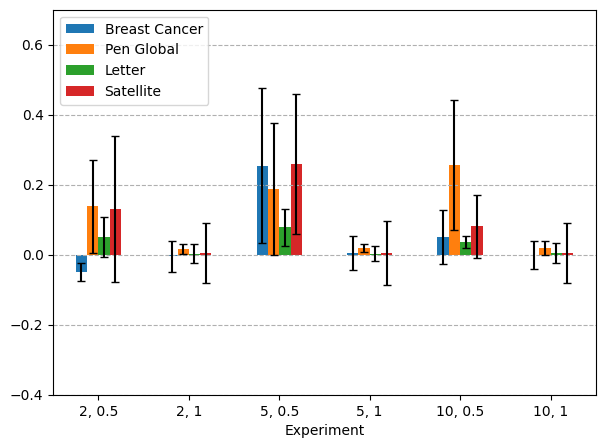

In [178]:
bias_table = pd.DataFrame(bias_table)
ax = bias_table.plot(kind='bar', x='Experiment', y=['Breast Cancer avg', 'Pen Global avg', 'Letter avg', 'Satellite avg'], yerr=[bias_table['Breast Cancer std'], bias_table['Pen Global std'], bias_table['Letter std'], bias_table['Satellite std']], capsize=3)
ax.grid(axis='y', linestyle='--')
ax.set_xticklabels(bias_table['Experiment'], rotation=0)
ax.legend(['Breast Cancer', 'Pen Global', 'Letter', 'Satellite'])

ax.set_ylim(ylim)

plt.savefig(f'{path}/bias_sve{exp_type}.pdf')

plt.show()

# Qual è l'impatto del bias ESVDD?

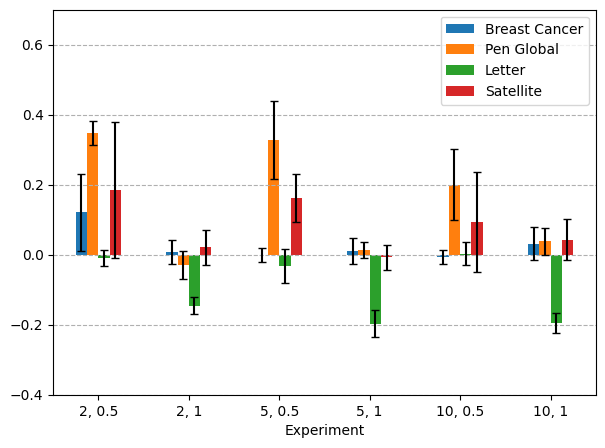

In [179]:
bias_table = []

for client_amount in [2,5,10]:
    for cf in [.5, 1]:
        row = {
            'Experiment': f'{client_amount}, {cf}'
        }
        for dataset in datasets:
            data = pd.read_csv(f'/Users/maxfrax/Downloads/{dataset}.csv')
            try:
                health_check(data)
            except:
                print(f'Failed for {dataset}')
                raise

            data_amount = data[data['parameters/clients_amount'] == client_amount]
            data_cf = data_amount[data_amount['parameters/client_fraction'] == cf]
            data_exp = data_cf[data_cf['parameters/experiment'] == 'ensemble_flbsv_noisy'].sort_values('parameters/iid_dataset')

            central_diff = data_exp.iloc[1]['results/avg_auc'] - data_exp.iloc[0]['results/avg_auc']
            std_diff = np.sqrt(np.square(data_exp.iloc[1]['results/std_auc']) + np.square(data_exp.iloc[0]['results/std_auc']))

            # TODO Da espandere con i veri valori
            dname = dataset.replace(exp_type, '').replace('_', ' ').title()
            row[f"{dname} avg"] = central_diff
            row[f"{dname} std"] = std_diff

        bias_table.append(row)

bias_table = pd.DataFrame(bias_table)
ax = bias_table.plot(kind='bar', x='Experiment', y=['Breast Cancer avg', 'Pen Global avg', 'Letter avg', 'Satellite avg'], yerr=[bias_table['Breast Cancer std'], bias_table['Pen Global std'], bias_table['Letter std'], bias_table['Satellite std']], capsize=3)
ax.grid(axis='y', linestyle='--')
ax.set_xticklabels(bias_table['Experiment'], rotation=0)
ax.legend(['Breast Cancer', 'Pen Global', 'Letter', 'Satellite'])

ax.set_ylim(ylim)

plt.savefig(f'{path}/bias_esvdd{exp_type}.pdf')

plt.show()
            

# Qual è l'impatto di client fraction su SVE?

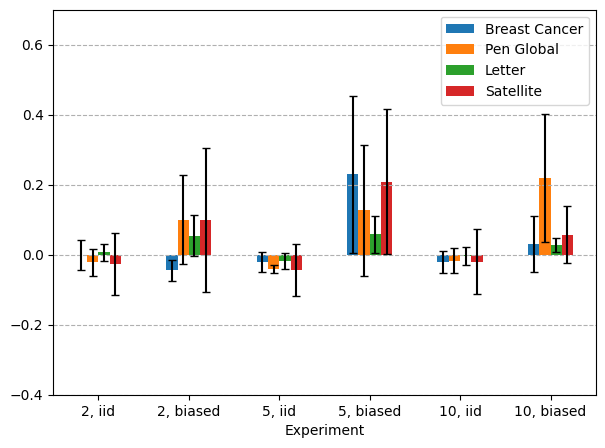

In [180]:
cf_table = []

for client_amount in [2,5,10]:
    for iid in ['iid', 'biased']:
        row = {
            'Experiment': f'{client_amount}, {iid}'
        }
        for dataset in datasets:
            data = pd.read_csv(f'/Users/maxfrax/Downloads/{dataset}.csv')
            try:
                health_check(data)
            except:
                print(f'Failed for {dataset}')
                raise

            data_amount = data[data['parameters/clients_amount'] == client_amount]
            data_iid = data_amount[data_amount['parameters/iid_dataset'] == iid]
            data_exp = data_iid[data_iid['parameters/experiment'] == 'dp_flbsv_noisy'].sort_values('parameters/client_fraction', ascending=True)

            central_diff = data_exp.iloc[1]['results/avg_auc'] - data_exp.iloc[0]['results/avg_auc']
            std_diff = np.sqrt(np.square(data_exp.iloc[1]['results/std_auc']) + np.square(data_exp.iloc[0]['results/std_auc']))

            # TODO Da espandere con i veri valori
            dname = dataset.replace(exp_type, '').replace('_', ' ').title()
            row[f"{dname} avg"] = central_diff
            row[f"{dname} std"] = std_diff

        cf_table.append(row)

cf_table = pd.DataFrame(cf_table)
ax = cf_table.plot(kind='bar', x='Experiment', y=['Breast Cancer avg', 'Pen Global avg', 'Letter avg', 'Satellite avg'], yerr=[cf_table['Breast Cancer std'], cf_table['Pen Global std'], cf_table['Letter std'], cf_table['Satellite std']], capsize=3)
ax.grid(axis='y', linestyle='--')
ax.set_xticklabels(cf_table['Experiment'], rotation=0)
ax.legend(['Breast Cancer', 'Pen Global', 'Letter', 'Satellite'])
ax.set_ylim(ylim)

plt.savefig(f'{path}/cf_sve{exp_type}.pdf')

plt.show()
            

# Qual è l'impatto di client fraction su ESVDD?

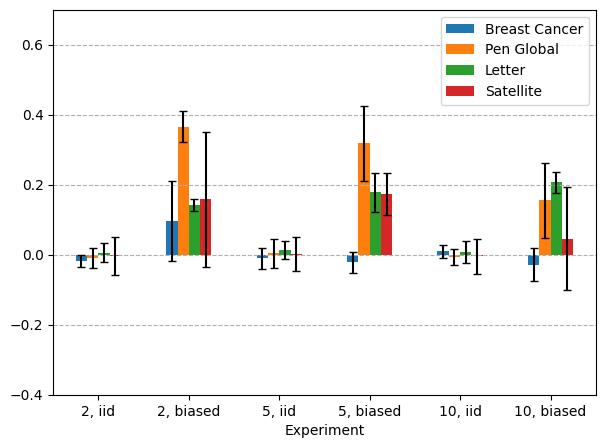

In [181]:
cf_table = []

for client_amount in [2,5,10]:
    for iid in ['iid', 'biased']:
        row = {
            'Experiment': f'{client_amount}, {iid}'
        }
        for dataset in datasets:
            data = pd.read_csv(f'/Users/maxfrax/Downloads/{dataset}.csv')
            try:
                health_check(data)
            except:
                print(f'Failed for {dataset}')
                raise

            data_amount = data[data['parameters/clients_amount'] == client_amount]
            data_iid = data_amount[data_amount['parameters/iid_dataset'] == iid]
            data_exp = data_iid[data_iid['parameters/experiment'] == 'ensemble_flbsv_noisy'].sort_values('parameters/client_fraction', ascending=True)

            central_diff = data_exp.iloc[1]['results/avg_auc'] - data_exp.iloc[0]['results/avg_auc']
            std_diff = np.sqrt(np.square(data_exp.iloc[1]['results/std_auc']) + np.square(data_exp.iloc[0]['results/std_auc']))

            # TODO Da espandere con i veri valori
            dname = dataset.replace(exp_type, '').replace('_', ' ').title()
            row[f"{dname} avg"] = central_diff
            row[f"{dname} std"] = std_diff

        cf_table.append(row)

cf_table = pd.DataFrame(cf_table)
ax = cf_table.plot(kind='bar', x='Experiment', y=['Breast Cancer avg', 'Pen Global avg', 'Letter avg', 'Satellite avg'], yerr=[cf_table['Breast Cancer std'], cf_table['Pen Global std'], cf_table['Letter std'], cf_table['Satellite std']], capsize=3)
ax.grid(axis='y', linestyle='--')
ax.set_xticklabels(cf_table['Experiment'], rotation=0)
ax.legend(['Breast Cancer', 'Pen Global', 'Letter', 'Satellite'])
ax.set_ylim(ylim)

plt.savefig(f'{path}/cf_esvdd{exp_type}.pdf')

plt.show()

# Qual è l'impatto del rumore su SVE?

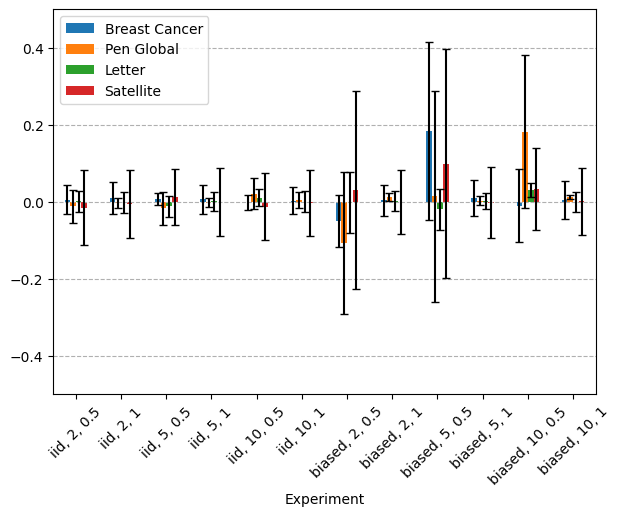

In [182]:
noise_table = []

for iid in ['iid', 'biased']:
    for client_amount in [2,5,10]:
        for cf in [0.5, 1]:
            row = {
                'Experiment': f'{iid}, {client_amount}, {cf}'
            }
            for dataset in datasets:
                data = pd.read_csv(f'/Users/maxfrax/Downloads/{dataset}.csv')
                try:
                    health_check(data)
                except:
                    print(f'Failed for {dataset}')
                    raise

                data_amount = data[data['parameters/clients_amount'] == client_amount]
                data_iid = data_amount[data_amount['parameters/iid_dataset'] == iid]
                data_cf = data_iid[data_iid['parameters/client_fraction'] == cf]
                data_exp = data_cf[data_cf['parameters/experiment'].str.contains('dp')]

                central_diff = data_exp.iloc[1]['results/avg_auc'] - data_exp.iloc[0]['results/avg_auc']
                std_diff = np.sqrt(np.square(data_exp.iloc[1]['results/std_auc']) + np.square(data_exp.iloc[0]['results/std_auc']))

                dname = dataset.replace(exp_type, '').replace('_', ' ').title()
                row[f"{dname} avg"] = central_diff
                row[f"{dname} std"] = std_diff
            noise_table.append(row)

noise_table = pd.DataFrame(noise_table)
ax = noise_table.plot(kind='bar', x='Experiment', y=['Breast Cancer avg', 'Pen Global avg', 'Letter avg', 'Satellite avg'], yerr=[noise_table['Breast Cancer std'], noise_table['Pen Global std'], noise_table['Letter std'], noise_table['Satellite std']], capsize=3)
ax.set_xticklabels(noise_table['Experiment'], rotation=45)
ax.grid(axis='y', linestyle='--')
ax.legend(['Breast Cancer', 'Pen Global', 'Letter', 'Satellite'])
ax.set_ylim(-0.5, 0.5)

plt.savefig(f'{path}/noise_sve{exp_type}.pdf', bbox_inches='tight')

plt.show()

# Qual è l'impatto del rumore su ESVDD?

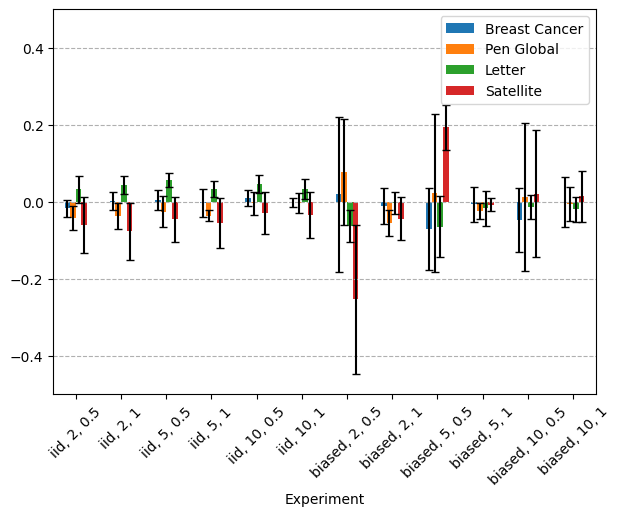

In [183]:
noise_table = []

for iid in ['iid', 'biased']:
    for client_amount in [2,5,10]:
        for cf in [0.5, 1]:
            row = {
                'Experiment': f'{iid}, {client_amount}, {cf}'
            }
            for dataset in datasets:
                data = pd.read_csv(f'/Users/maxfrax/Downloads/{dataset}.csv')
                try:
                    health_check(data)
                except:
                    print(f'Failed for {dataset}')
                    raise

                data_amount = data[data['parameters/clients_amount'] == client_amount]
                data_iid = data_amount[data_amount['parameters/iid_dataset'] == iid]
                data_cf = data_iid[data_iid['parameters/client_fraction'] == cf]
                data_exp = data_cf[data_cf['parameters/experiment'].str.contains('ensemble')]

                central_diff = data_exp.iloc[1]['results/avg_auc'] - data_exp.iloc[0]['results/avg_auc']
                std_diff = np.sqrt(np.square(data_exp.iloc[1]['results/std_auc']) + np.square(data_exp.iloc[0]['results/std_auc']))

                dname = dataset.replace(exp_type, '').replace('_', ' ').title()
                row[f"{dname} avg"] = central_diff
                row[f"{dname} std"] = std_diff
            noise_table.append(row)

noise_table = pd.DataFrame(noise_table)
ax = noise_table.plot(kind='bar', x='Experiment', y=['Breast Cancer avg', 'Pen Global avg', 'Letter avg', 'Satellite avg'], yerr=[noise_table['Breast Cancer std'], noise_table['Pen Global std'], noise_table['Letter std'], noise_table['Satellite std']], capsize=3)
ax.set_xticklabels(noise_table['Experiment'], rotation=45)
ax.grid(axis='y', linestyle='--')
ax.legend(['Breast Cancer', 'Pen Global', 'Letter', 'Satellite'])
ax.set_ylim(-0.5, 0.5)

plt.savefig(f'{path}/noise_esvdd{exp_type}.pdf', bbox_inches='tight')

plt.show()